In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster



In [48]:
df=pd.read_excel('P659_World_development_dataset.xlsx')
df.head()

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,"$54,790,058,957",0.035,$60,...,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,"$102,000,000","$193,000,000"
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,"$9,129,594,819",0.034,$22,...,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,"$34,000,000","$146,000,000"
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,"$2,359,122,303",0.043,$15,...,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,"$77,000,000","$50,000,000"
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,"$5,788,311,645",0.047,$152,...,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,"$227,000,000","$209,000,000"
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,"$2,610,959,139",0.051,$12,...,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,"$23,000,000","$30,000,000"


In [49]:

country_names = df['Country']


df = df.drop('Country', axis=1)

In [50]:
# Save country names
# Check if 'Country' column still exists in df. If not, it means it was already handled by a previous cell.
if 'Country' in df.columns:
    country_names = df['Country']
    print("Country names saved from 'df'.")
else:
    print("The 'Country' column was not found in 'df'. Assuming it was already saved by a prior step.")
    # If 'country_names' variable is not defined at this point, it would still cause an error later
    # but for fixing this specific KeyError, this handles the column access.
    # In this notebook's flow, 'country_names' should already be defined from cell 7292dd73-93e7-46e4-a2fc-3460-4ec7-92be-213f5627c23e.

The 'Country' column was not found in 'df'. Assuming it was already saved by a prior step.


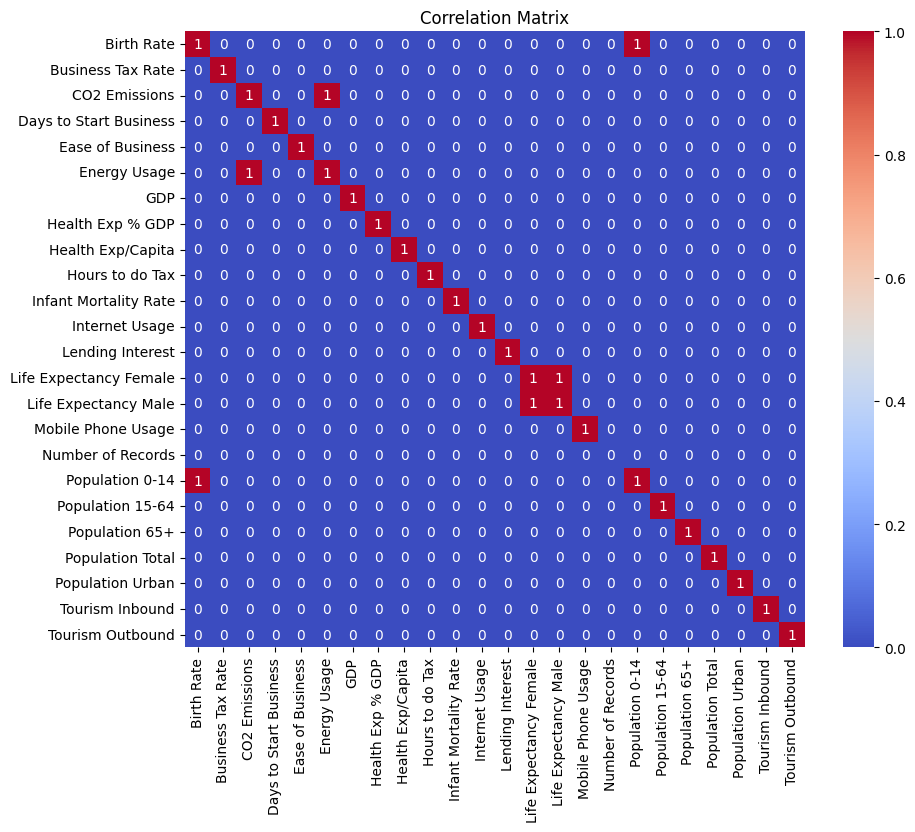

Dropped columns: ['Energy Usage', 'Life Expectancy Male', 'Population 0-14']


In [51]:
# Clean numeric columns before calculating correlation
for col in df.columns:
    if df[col].dtype == 'object':  # Check if column is of object type (string)
        # Convert to string to ensure .str accessor works and replace non-numeric chars
        temp_col = df[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.strip()

        # If it contains '%', remove it and divide by 100
        if temp_col.str.contains('%').any():
            df[col] = pd.to_numeric(temp_col.str.replace('%', '', regex=False), errors='coerce') / 100
        else:
            # Try to convert to float directly if no '%' or after cleaning
            df[col] = pd.to_numeric(temp_col, errors='coerce')

# Drop columns that could not be converted to numeric (e.g., if they were purely text)
df = df.select_dtypes(include=np.number)

corr_matrix = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix>0.9,annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

df = df.drop(columns=to_drop)
print("Dropped columns:", to_drop)

In [52]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [53]:
from sklearn.impute import SimpleImputer

# Impute missing values after scaling and before PCA
imputer = SimpleImputer(strategy='mean')
X_scaled_imputed = imputer.fit_transform(X_scaled)

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled_imputed)

print("Original:", X_scaled.shape)
print("Reduced:", X_pca.shape)

Original: (2704, 21)
Reduced: (2704, 13)


# HIERARCHICAL CLUSTERING

In [54]:
linked = linkage(X_pca, method='ward')

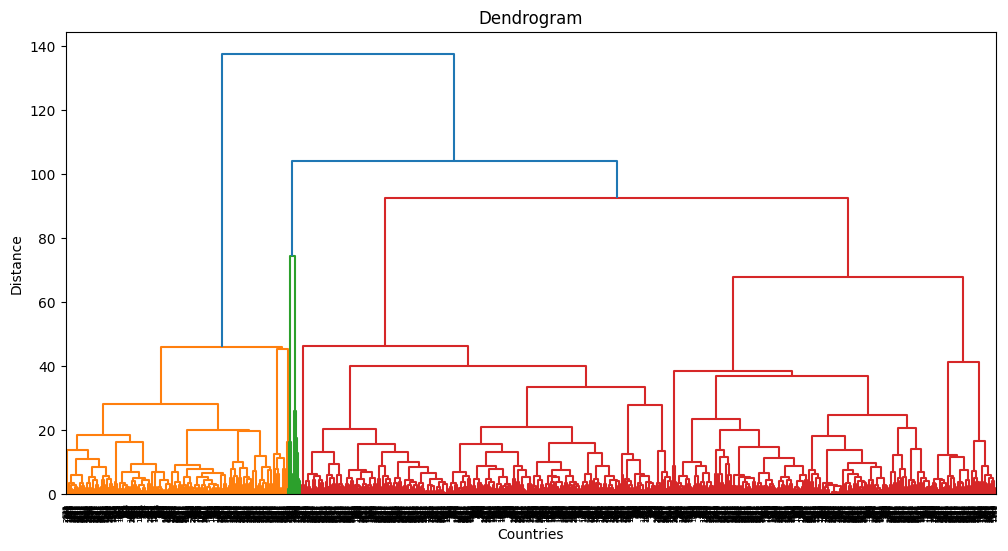

In [55]:
plt.figure(figsize=(12,6))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Countries")
plt.ylabel("Distance")
plt.show()

In [56]:
hc_labels = fcluster(linked, t=3, criterion='maxclust')

df['HC_Cluster'] = hc_labels

In [57]:
hc_score = silhouette_score(X_pca, hc_labels)
print("Hierarchical Silhouette Score:", hc_score)

Hierarchical Silhouette Score: 0.312048785030347


# K-Means Clustering

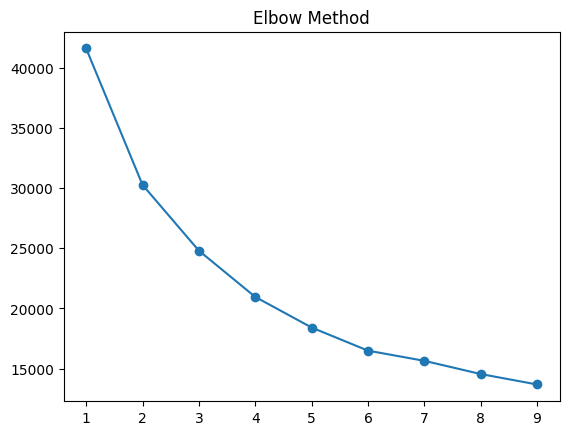

In [58]:
wcss = []
for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss, marker='o')
plt.title("Elbow Method")
plt.show()

#### apply k-mean cluster

In [59]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)

df['KMeans_Cluster'] = kmeans_labels

**Silhoutte_score**

In [60]:
k_score = silhouette_score(X_pca, kmeans_labels)
print("K-Means Score:", k_score)

K-Means Score: 0.31524287385510286


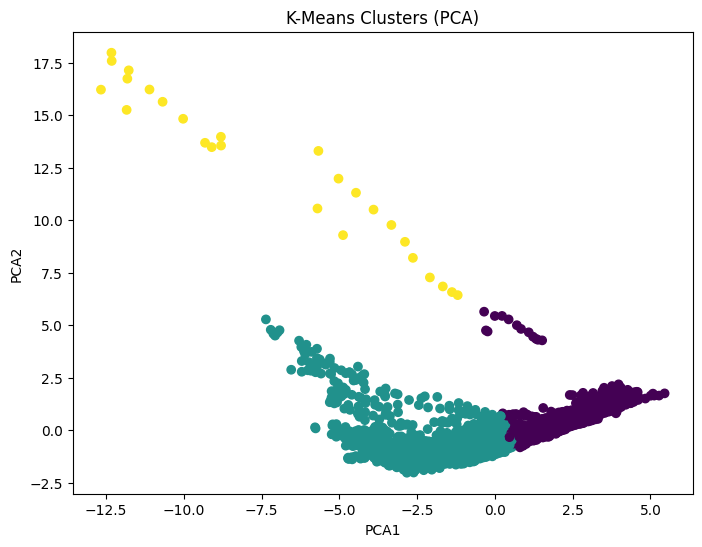

In [61]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['KMeans_Cluster'])
plt.title("K-Means Clusters (PCA)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()


# DBSCAN (Tuned)

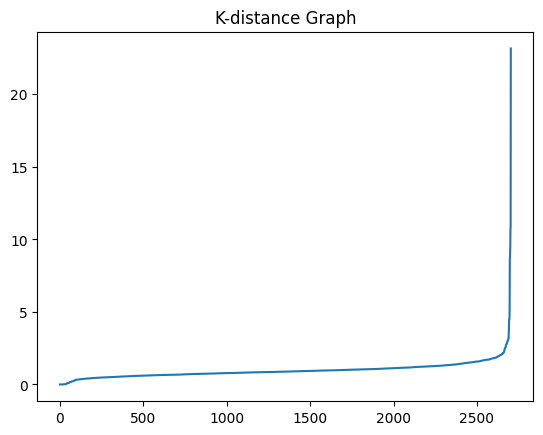

In [62]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled_imputed)
distances, _ = neighbors_fit.kneighbors(X_scaled_imputed)

distances = np.sort(distances[:,4])
plt.plot(distances)
plt.title("K-distance Graph")
plt.show()

In [63]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled_imputed)

df['DBSCAN_Cluster'] = db_labels

In [64]:
if len(set(db_labels)) > 1:
    db_score = silhouette_score(X_scaled_imputed, db_labels)
    print("DBSCAN Score:", db_score)
else:
    print("DBSCAN not suitable")

DBSCAN Score: -0.09144554394471151


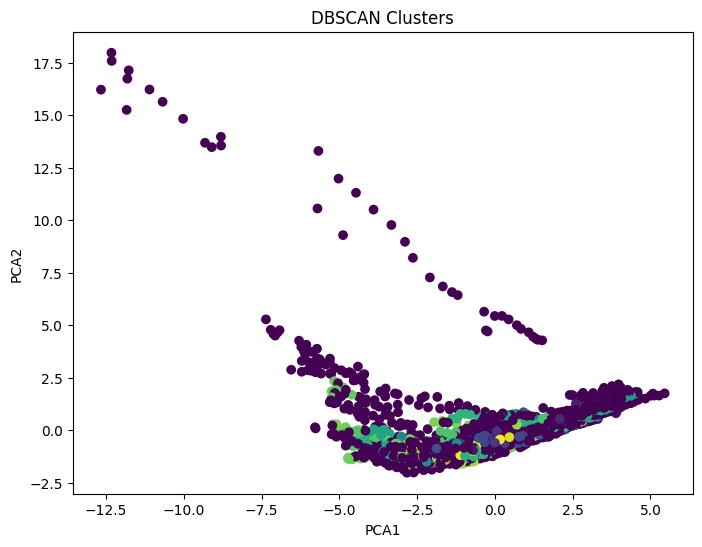

In [65]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['DBSCAN_Cluster'])
plt.title("DBSCAN Clusters")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

In [66]:
# Prediction
clusters = kmeans.predict(X_pca)

In [67]:
cluster_names = {
    0: "Developed",
    1: "Developing",
    2: "Underdeveloped"
}

df['Cluster_Name'] = df['KMeans_Cluster'].map(cluster_names)
df['Country'] = country_names

result = df[['Country', 'Cluster_Name']]
result.head()

,Country,Cluster_Name
0,Algeria,Developed
1,Angola,Developed
2,Benin,Developed
3,Botswana,Developed
4,Burkina Faso,Developed


In [68]:
pip install streamlit scikit-learn pandas numpy matplotlib

In [69]:
import pickle

# Save scaler, PCA, and model
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(pca, open("pca.pkl", "wb"))
pickle.dump(kmeans, open("kmeans.pkl", "wb"))

In [70]:
import streamlit as st

**Load the models**

In [71]:
scaler = pickle.load(open("scaler.pkl", "rb"))
pca = pickle.load(open("pca.pkl", "rb"))
model = pickle.load(open("kmeans.pkl", "rb"))

In [72]:
st.title("Global Development Clustering App")

2026-04-12 18:34:33.012 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 18:34:33.015 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 18:34:33.016 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [73]:
st.write("Upload dataset to classify countries into clusters")

2026-04-12 18:34:33.031 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 18:34:33.033 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 18:34:33.034 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [74]:
uploaded_file = st.file_uploader("Upload CSV file", type=["csv"])

2026-04-12 18:34:33.042 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 18:34:33.044 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 18:34:33.045 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 18:34:33.047 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 18:34:33.048 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 18:34:33.050 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [75]:
if uploaded_file is not None:
    df = pd.read_csv(uploaded_file)

    st.write("### Original Data")
    st.dataframe(df.head())

In [76]:
st.write("### Cluster Results")
st.dataframe(result)

2026-04-12 18:34:33.067 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 18:34:33.069 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 18:34:33.069 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 18:34:33.078 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 18:34:33.080 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 18:34:33.082 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

**Visualization**

In [77]:
 st.write("### Cluster Visualization")

2026-04-12 18:34:33.094 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 18:34:33.096 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 18:34:33.097 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


**Define clusters in the form of plots**

In [78]:
fig, ax = plt.subplots()
scatter = ax.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_title("Clusters")

Text(0.5, 1.0, 'Clusters')

In [79]:
  st.pyplot(fig)

2026-04-12 18:34:33.135 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 18:34:33.437 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 18:34:33.438 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 18:34:33.439 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [80]:
import joblib

# Save scaler, PCA, and model using joblib
joblib.dump(scaler, "scaler.joblib")
joblib.dump(pca, "pca.joblib")
joblib.dump(kmeans, "kmeans.joblib")
print("Models saved successfully using joblib: scaler.joblib, pca.joblib, kmeans.joblib")

Models saved successfully using joblib: scaler.joblib, pca.joblib, kmeans.joblib


In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import pycountry
from sklearn.impute import SimpleImputer

# =========================
# PAGE CONFIG
# =========================
st.set_page_config(page_title="Global Dev Clustering", layout="wide")

# =========================
# DARK UI
# =========================
st.markdown("""
<style>
body {background-color: #0f172a; color: white;}
.block-container {padding: 1.5rem;}
.card {
    background: #1e293b;
    padding: 15px;
    border-radius: 12px;
    margin-bottom: 12px;
}
.metric {
    font-size: 20px;
    font-weight: bold;
    color: #38bdf8;
}
</style>
""", unsafe_allow_html=True)

# =========================
# FLAG FUNCTION
# =========================
def get_flag(country_name):
    try:
        country = pycountry.countries.search_fuzzy(country_name)[0]
        code = country.alpha_2
        return "".join(chr(127397 + ord(c)) for c in code)
    except:
        return ""

# =========================
# SIDEBAR
# =========================
st.sidebar.title("🌍 Global Dev Clustering")
st.sidebar.caption("Unsupervised ML Project")

uploaded_file = st.sidebar.file_uploader("📂 Upload dataset", type=["csv", "xlsx"])

menu = st.sidebar.radio("📊 Navigation", [
    "Overview & EDA",
    "Feature Analysis",
    "Clustering Models",
    "Model Comparison",
    "Country Explorer"
])

# =========================
# LOAD MODELS
# =========================
@st.cache_resource
def load_models():
    scaler = joblib.load("scaler.joblib")
    pca = joblib.load("pca.joblib")
    kmeans = joblib.load("kmeans.joblib")
    columns = joblib.load("columns.joblib")
    return scaler, pca, kmeans, columns

try:
    scaler, pca, model, columns = load_models()
except:
    st.error("❌ Missing model files (.joblib)")
    st.stop()

# =========================
# MAIN APP
# =========================
if uploaded_file:

    # LOAD DATA
    if uploaded_file.name.endswith(".csv"):
        df = pd.read_csv(uploaded_file)
    else:
        df = pd.read_excel(uploaded_file)

    if "Country" not in df.columns:
        st.error("Dataset must contain 'Country'")
        st.stop()

    country_names = df["Country"]

    # =========================
    # COUNTRY FILTER
    # =========================
    st.sidebar.markdown("### 🌐 Select Country")

    country_list = sorted(country_names.unique())

    selected_country = st.sidebar.selectbox(
        "Choose Country",
        ["All Countries"] + country_list,
        format_func=lambda x: f"{get_flag(x)} {x}" if x != "All Countries" else x
    )

    # =========================
    # CLEAN DATA
    # =========================
    df_clean = df.drop("Country", axis=1).copy()

    for col in columns:
        if col not in df_clean.columns:
            df_clean[col] = np.nan

    df_clean = df_clean[columns]

    for col in df_clean.columns:
        temp = df_clean[col].astype(str)\
            .str.replace('$', '', regex=False)\
            .str.replace(',', '', regex=False)

        if temp.str.contains('%').any():
            df_clean[col] = pd.to_numeric(
                temp.str.replace('%', '', regex=False),
                errors='coerce'
            ) / 100
        else:
            df_clean[col] = pd.to_numeric(temp, errors='coerce')

    # =========================
    # IMPUTATION (NO NaN)
    # =========================
    imputer = SimpleImputer(strategy="mean")
    df_clean[:] = imputer.fit_transform(df_clean)

    # =========================
    # TRANSFORM
    # =========================
    X_scaled = scaler.transform(df_clean)
    X_pca = pca.transform(X_scaled)

    clusters = model.predict(X_pca)
    df["Cluster"] = clusters

    # =========================
    # 🔥 CLUSTER LABELS (FIXED)
    # =========================
    cluster_data = df_clean.copy()
    cluster_data["Cluster"] = clusters

    # Ensure GDP is numeric
    cluster_data["GDP"] = pd.to_numeric(cluster_data["GDP"], errors="coerce")

    cluster_means = cluster_data.groupby("Cluster")["GDP"].mean().sort_values()

    cluster_labels = {}
    labels = ["Low Income", "Middle Income", "High Income"]

    for i, cluster_id in enumerate(cluster_means.index):
        if i < len(labels):
            cluster_labels[cluster_id] = labels[i]
        else:
            cluster_labels[cluster_id] = f"Cluster {cluster_id}"

    df["Cluster Name"] = df["Cluster"].map(cluster_labels)

    # =========================
    # FILTER DATA
    # =========================
    if selected_country != "All Countries":
        df_filtered = df[df["Country"] == selected_country]
        df_clean_filtered = df_clean.loc[df_filtered.index]
        clusters_filtered = df_filtered["Cluster"]
    else:
        df_filtered = df
        df_clean_filtered = df_clean
        clusters_filtered = clusters

    # =========================
    # HEADER
    # =========================
    if selected_country != "All Countries":
        st.markdown(f"## {get_flag(selected_country)} {selected_country}")
    else:
        st.markdown("## 🌍 All Countries Overview")

    # =========================
    # OVERVIEW
    # =========================
    if menu == "Overview & EDA":

        col1, col2, col3 = st.columns(3)

        if selected_country != "All Countries":
            col1.metric("🌍 Country", selected_country)
            col3.metric("🧠 Cluster", df_filtered["Cluster Name"].iloc[0])
        else:
            col1.metric("🌍 Countries", df_filtered["Country"].nunique())
            col3.metric("🧠 Total Clusters", df["Cluster"].nunique())

        col2.metric("📊 Features", df_clean_filtered.shape[1])

        st.dataframe(df_filtered.head())
        st.bar_chart(df_clean_filtered.isnull().sum())

        corr = df_clean_filtered.corr()
        fig, ax = plt.subplots(figsize=(8,6))
        im = ax.imshow(corr)
        plt.colorbar(im)
        st.pyplot(fig)

    # =========================
    # FEATURE ANALYSIS
    # =========================
    elif menu == "Feature Analysis":

        feature = st.selectbox("Select Feature", df_clean_filtered.columns)

        col1, col2, col3 = st.columns(3)
        col1.metric("Mean", round(df_clean_filtered[feature].mean(), 2))
        col2.metric("Max", round(df_clean_filtered[feature].max(), 2))
        col3.metric("Min", round(df_clean_filtered[feature].min(), 2))

        fig, ax = plt.subplots()
        ax.hist(df_clean_filtered[feature], bins=30)
        st.pyplot(fig)

    # =========================
    # CLUSTERING
    # =========================
    elif menu == "Clustering Models":

        st.bar_chart(pd.Series(clusters_filtered).value_counts())

        fig, ax = plt.subplots()
        ax.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
        st.pyplot(fig)

        st.dataframe(df_filtered.head())

    # =========================
    # MODEL COMPARISON
    # =========================
    elif menu == "Model Comparison":

        cluster_data = df_clean_filtered.copy()
        cluster_data["Cluster"] = clusters_filtered

        st.dataframe(cluster_data.groupby("Cluster").mean())

    # =========================
    # COUNTRY EXPLORER
    # =========================
    elif menu == "Country Explorer":

        if selected_country == "All Countries":
            st.warning("Please select a country")
        else:
            row = df_filtered.iloc[0]
            row_clean = df_clean_filtered.iloc[0]

            st.markdown(f"### {get_flag(selected_country)} {selected_country}")
            st.write(row_clean)

else:
    st.info("⬅️ Upload dataset to begin")


2026-04-12 18:47:33.069 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 18:47:33.073 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 18:47:33.075 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 18:47:33.081 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 18:47:33.082 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 18:47:33.086 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 18:47:33.092 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 18:47:33.093 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

Importing columns (Could not retrieve original training columns. Ensure the application can access them).

In [84]:
import joblib

# Ensure df is defined by running previous data loading and preprocessing cells.
# If df is not defined, this cell will indicate the problem rather than directly erroring.

# The 'df' dataframe, if all previous cells were run, now contains cluster assignment columns
# and the 'Country' column (re-added for result display).
# To save only the original numerical feature columns that were used for scaling and PCA,
# we need to exclude these cluster-related columns and the 'Country' column.

if 'df' in locals() or 'df' in globals():
    known_cluster_cols = ['HC_Cluster', 'KMeans_Cluster', 'DBSCAN_Cluster', 'Cluster_Name']

    # Filter out cluster columns and the 'Country' column to get the original feature set
    feature_columns = [col for col in df.columns if col not in known_cluster_cols and col != 'Country']

    joblib.dump(feature_columns, "columns.joblib")
    print("Feature column names saved successfully to columns.joblib")
else:
    print("Error: DataFrame 'df' is not defined. Please ensure preceding cells that define and preprocess 'df' are executed.")


Feature column names saved successfully to columns.joblib
